In [ ]:
# LightGBM + MAPIE Conformal Prediction — Ames Housing
# Point predictions with 90% coverage-guaranteed prediction intervals using split conformal prediction.

## 1. Imports

In [2]:
!pip install lightgbm mapie

In [3]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMRegressor
from mapie.regression import SplitConformalRegressor  # MapieRegressor renamed in MAPIE v1.0+

## 2. Load Dataset
Downloads the Ames Housing dataset from OpenML on first run and caches it to `data/ames_housing.csv`.

In [4]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# create data folder
os.makedirs("data", exist_ok=True)

# load your full dataset
df = pd.read_csv("/Users/simardhanda/Desktop/research/data/AmesHousing.csv")

# split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# save
train_df.to_csv("data/train.csv", index=False)
test_df.to_csv("data/test.csv", index=False)

print("Split done")

Split done


In [5]:
TRAIN_PATH = os.path.join("data", "train.csv")
TEST_PATH  = os.path.join("data", "test.csv")

# Load and merge both files, then shuffle
df = pd.concat([pd.read_csv(TRAIN_PATH), pd.read_csv(TEST_PATH)], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns")
df.head(3)

Loaded 2930 rows × 82 columns


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1835,533205110,120,FV,45.0,4379,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2007,WD,Normal,214000
1,2780,907194130,60,RL,65.0,14006,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,2,2006,WD,Normal,192500
2,1965,535453150,20,RL,70.0,7315,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,140000


## 3. Prepare Features & Target

In [6]:
TARGET = "SalePrice"

# Drop rows missing the target
df = df.dropna(subset=[TARGET])

X = df.drop(columns=[TARGET])
y = np.log1p(df[TARGET])  # log-transform to stabilise variance

# Encode categorical columns as integers (LightGBM handles them natively)
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

print(f"Features: {X.shape[1]}  |  Categorical encoded: {len(cat_cols)}")

Features: 81  |  Categorical encoded: 43


## 4. Train / Calibration / Test Split
MAPIE split-conformal requires a held-out calibration set separate from training.
Split: **60% train | 20% calibration | 20% test**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_cal,  y_train, y_cal  = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

print(f"Train: {len(X_train)} | Calibration: {len(X_cal)} | Test: {len(X_test)}")

Train: 1758 | Calibration: 586 | Test: 586


In [9]:
pip install --upgrade mapie

Note: you may need to restart the kernel to use updated packages.


## 5. Train LightGBM & Wrap with MAPIE
- `fit()` trains the base model on `X_train`
- `conformalize()` calibrates nonconformity scores on the held-out `X_cal`

In [8]:
lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)

mapie = SplitConformalRegressor(estimator=lgbm, confidence_level=0.90, prefit=False)
mapie.fit(X_train, y_train)           # trains base model
mapie.conformalize(X_cal, y_cal)      # calibrates nonconformity scores on cal set

print("Model trained and calibrated.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000681 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4060
[LightGBM] [Info] Number of data points in the train set: 1758, number of used features: 76
[LightGBM] [Info] Start training from score 12.025755
Model trained and calibrated.


## 6. Predict with 90% Prediction Intervals

In [9]:
#y_pred = mapie.predict(X_test)                # point predictions
y_pred, y_pis  = mapie.predict_interval(X_test)       # shape: (n_samples, 2) → [lower, upper]

y_lower = y_pis[:, 0].ravel()
y_upper = y_pis[:, 1].ravel()
y_pred  = y_pred.ravel()

## 7. Evaluate Coverage & Interval Width

In [10]:
coverage = np.mean((y_test.values >= y_lower) & (y_test.values <= y_upper))
interval_width = np.mean(y_upper - y_lower)

print(f"Empirical coverage : {coverage:.3f}  (target ≥ 0.90)")
print(f"Mean interval width: {interval_width:.3f}  (log-scale)")

Empirical coverage : 0.882  (target ≥ 0.90)
Mean interval width: 0.368  (log-scale)


## 8. Sample Predictions

In [11]:
results = pd.DataFrame({
    "actual_log":    y_test.values[:10],
    "predicted_log": y_pred[:10],
    "lower_90":      y_lower[:10],
    "upper_90":      y_upper[:10],
})
results

,actual_log,predicted_log,lower_90,upper_90
0,11.751950,11.728653,11.544861,11.912445
1,12.160034,12.141824,11.958032,12.325616
2,11.373675,11.427258,11.243466,11.611050
3,12.637956,12.395627,12.211835,12.579419
4,11.289794,11.567019,11.383227,11.750812
5,12.339296,12.006654,11.822862,12.190446
6,12.271397,12.324528,12.140735,12.508320
7,12.396697,12.218695,12.034902,12.402487
8,12.165256,12.162200,11.978408,12.345992
9,11.813037,11.826684,11.642892,12.010477


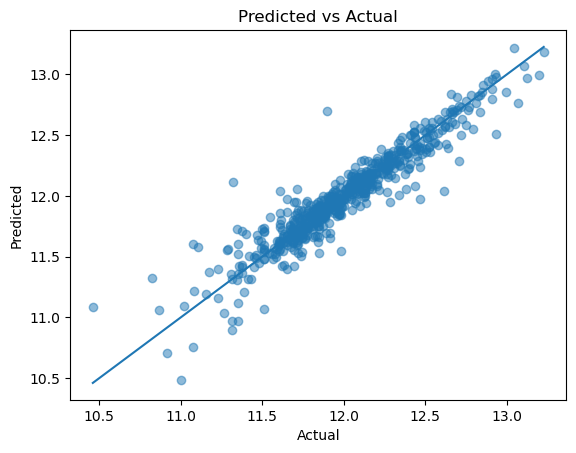

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

# perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

In [28]:
coverage = np.mean((y_test >= y_lower) & (y_test <= y_upper))
print("Coverage:", coverage)

Coverage: 0.8822525597269625


In [39]:
print(np.__version__)

1.26.4


In [13]:
import random
random.seed(42)

arr = np.array([1, 2, 3,4,5,6,7,8,9,0])
arr[[7,8,9]]
rng = np.random.default_rng(seed=42)
array_1d = rng.integers(1, 8, size=3)
array_1d


array([1, 6, 5])

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import random
# convert to real prices
y_pred_real  = np.expm1(y_pred)
y_lower_real = np.expm1(y_lower)
y_upper_real = np.expm1(y_upper)

# take 8 samples
n = 8
rng = np.random.default_rng(seed=42)
random_points = rng.integers(0,586,size=8)
print(random_points)
means = y_pred_real[random_points]
lower = y_lower_real[random_points]
upper = y_upper_real[random_points]

labels = [f"House {i+1}" for i in range(n)]
y_pos = np.arange(n)

[ 52 453 383 257 253 503  50 408]


In [ ]:
print(random.randint(0,586))

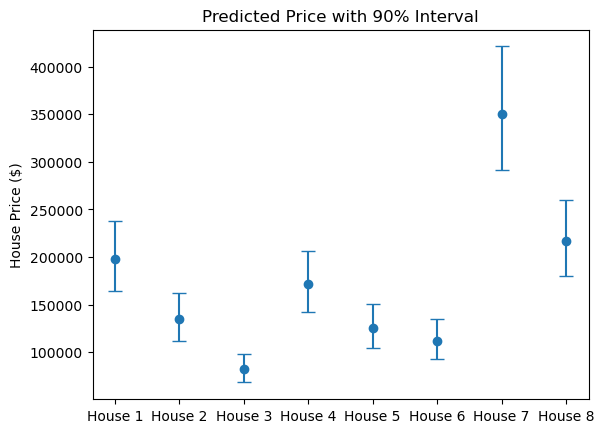

In [23]:
import numpy as np
import matplotlib.pyplot as plt

n = len(means)
x_pos = np.arange(n)
labels = [f"House {i+1}" for i in range(n)]

plt.figure()

plt.errorbar(
    x_pos,
    means,
    yerr=[means - lower, upper - means],
    fmt='o',
    capsize=5
)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Predicted Price with 90% Interval")

plt.show()

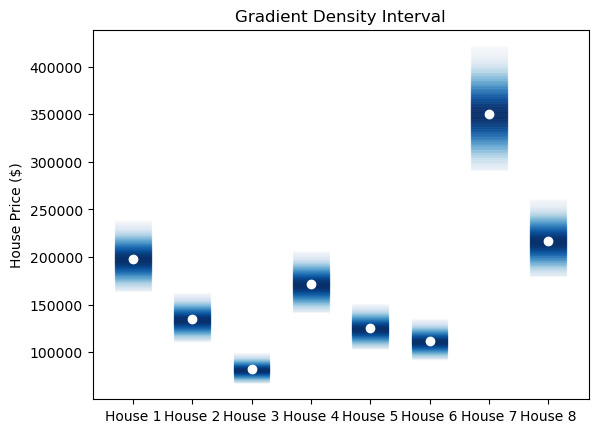

In [39]:
plt.figure()

for i in range(n):
    y = np.linspace(lower[i], upper[i], 200)
    center = means[i]
    
    density = np.exp(-((y - center)**2) / (2 * ((upper[i]-lower[i])/4)**2))
    density = density / density.max()
    
    for j in range(len(y)-1):
        plt.fill_between(
            [i-0.3, i+0.3],
            y[j], y[j+1],
            color=plt.cm.Blues(density[j]),
            alpha=density[j]*0.6
        )
    
    plt.scatter(i, center, color="white", zorder=3)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Gradient Density Interval")
plt.show()

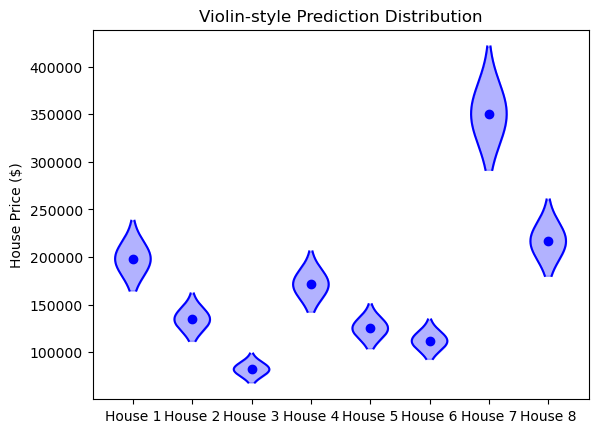

In [46]:
from scipy.stats import norm

plt.figure()

colors = plt.cm.tab10(np.linspace(0, 1, n))  # 👈 ADD THIS

for i in range(n):
    y = np.linspace(lower[i], upper[i], 200)
    mu = means[i]
    sigma = (upper[i] - lower[i]) / 4

    density = norm.pdf(y, mu, sigma)
    density = density / density.max() * 0.3

    c = "blue"

    plt.plot(i + density, y, color=c)
    plt.plot(i - density, y, color=c)
    plt.fill_betweenx(y, i - density, i + density, alpha=0.3, color=c)

    plt.scatter(i, mu, color=c)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Violin-style Prediction Distribution")
plt.show()

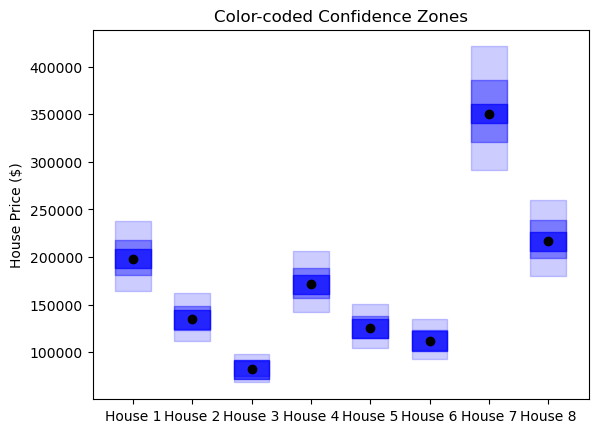

In [52]:
plt.figure()
c = "blue"

for i in range(n):
    mid_low = means[i] - (means[i] - lower[i]) / 2
    mid_high = means[i] + (upper[i] - means[i]) / 2

    # outer zone
    plt.fill_between([i-0.3, i+0.3],
                     lower[i], upper[i],
                     color=c, alpha=0.2)

    # mid zone
    plt.fill_between([i-0.3, i+0.3],
                     mid_low, mid_high,
                     color=c, alpha=0.4)

    # center zone
    plt.fill_between([i-0.3, i+0.3],
                     means[i]-10000,
                     means[i]+10000,
                     color=c, alpha=0.7)

    plt.scatter(i, means[i], color="black", zorder=3)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Color-coded Confidence Zones")
plt.show()

In [50]:
for i in range(n):
    print(
        f"{labels[i]}: Model predicts ${means[i]:,.0f}; "
        f"90% likely between ${lower[i]:,.0f} and ${upper[i]:,.0f}"
    )

House 1: Model predicts $124,075; 90% likely between $103,244 and $149,110
House 2: Model predicts $187,553; 90% likely between $156,065 and $225,395
House 3: Model predicts $91,789; 90% likely between $76,378 and $110,309
House 4: Model predicts $241,741; 90% likely between $201,155 and $290,517
House 5: Model predicts $105,557; 90% likely between $87,835 and $126,855
House 6: Model predicts $163,840; 90% likely between $136,333 and $196,898
House 7: Model predicts $225,150; 90% likely between $187,349 and $270,578
House 8: Model predicts $202,539; 90% likely between $168,535 and $243,405


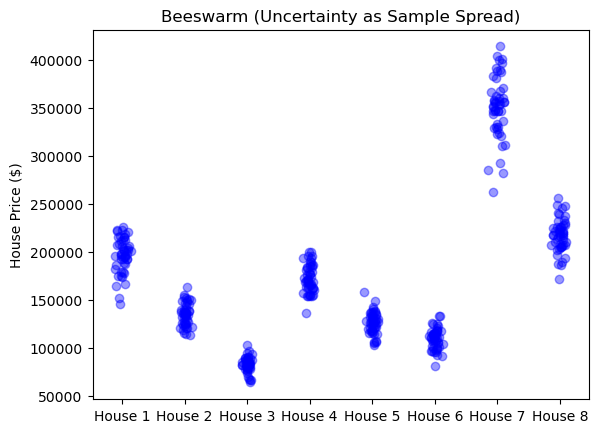

In [53]:
c = "blue"   # pick one color

plt.figure()

for i in range(n):
    samples = np.random.normal(
        means[i],
        (upper[i] - lower[i]) / 4,
        size=50
    )

    x_jitter = np.random.normal(i, 0.05, size=len(samples))

    plt.scatter(x_jitter, samples, color=c, alpha=0.4)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Beeswarm (Uncertainty as Sample Spread)")
plt.show()

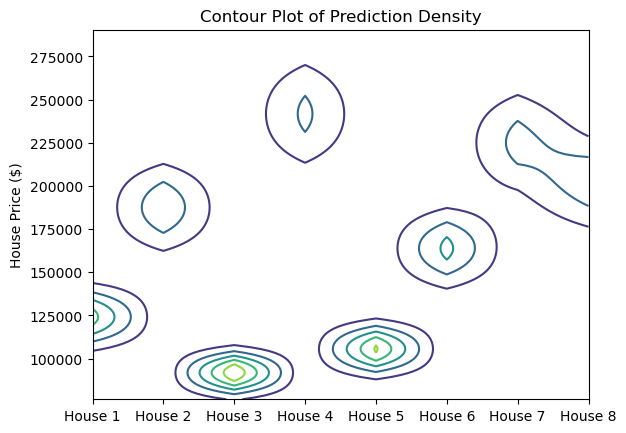

In [ ]:
plt.figure()

X, Y = np.meshgrid(x_pos, grid_y)
Z = np.zeros_like(X, dtype=float)

for i in range(n):
    mu = means[i]
    sigma = (upper[i] - lower[i]) / 4
    Z[:, i] = norm.pdf(grid_y, mu, sigma)

plt.contour(X, Y, Z, levels=5, color="blue")

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Contour Plot of Prediction Density")
plt.show()

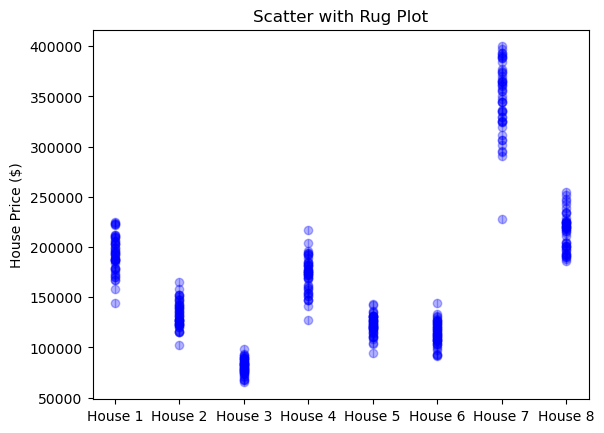

In [ ]:
c = "blue"

plt.figure()

for i in range(n):
    samples = np.random.normal(
        means[i],
        (upper[i] - lower[i]) / 4,
        size=50
    )

    plt.scatter([i]*len(samples), samples,
                color=c, alpha=0.3)

    plt.plot([i]*len(samples), samples,
             '|', color=c, alpha=0.3)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Scatter with Rug Plot")
plt.show()

In [27]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [55]:
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.pyplot as plt
import numpy as np

n = len(means)
x_pos = np.arange(n)

fig, ax = plt.subplots()

def update(frame):
    ax.clear()

    samples = []
    for i in range(n):
        sample = np.random.normal(
            means[i],
            (upper[i] - lower[i]) / 4
        )
        samples.append(sample)

    ax.scatter(x_pos, samples)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"House {i+1}" for i in range(n)])
    ax.set_ylabel("House Price ($)")
    ax.set_title("HOP: Possible Outcomes")
    ax.set_ylim(min(lower), max(upper))

ani = FuncAnimation(fig, update, frames=10, interval=200)

writer = PillowWriter(fps=5)

ani.save("hop.gif", writer=writer)

plt.close(fig)

In [ ]:
from scipy.stats import skew

for i in range(n):
    samples = np.random.normal(
        means[i],
        (upper[i] - lower[i]) / 4,
        size=1000   # more samples = better estimate
    )

    s = skew(samples)
    print(f"House {i+1} skewness: {s:.3f}")